# Imports

In [1]:
import sys
import os

sys.path.append("../")

import torch
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from src.datasets.change_detection_dataset import ChangeDetectionDataset

C:\Users\kritr\Downloads\INTERNSHIP\GalaxEye_Segmentation_Assignment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Create Dataset

In [2]:
dataset = ChangeDetectionDataset(
    root_dir="../dataset",
    split="train",
    image_size=512,
    augment=True
)

print("Dataset Size:", len(dataset))

Dataset Size: 2781


## Load one sample from the Dataset

In [3]:
sample = dataset[-500]

image = sample["image"]
mask = sample["mask"]
file_name = sample["file_name"]

print("File Name :", file_name)

print("\nIMAGE")
print("Shape :", image.shape)
print("Dtype :", image.dtype)

print("\nMASK")
print("Shape :", mask.shape)
print("Dtype :", mask.dtype)
print("Unique :", torch.unique(mask))

File Name : scene_08_000502_building_damage.tif

IMAGE
Shape : torch.Size([4, 512, 512])
Dtype : torch.float32

MASK
Shape : torch.Size([1, 512, 512])
Dtype : torch.float32
Unique : tensor([0., 1.])


## Visualising Processed Sample

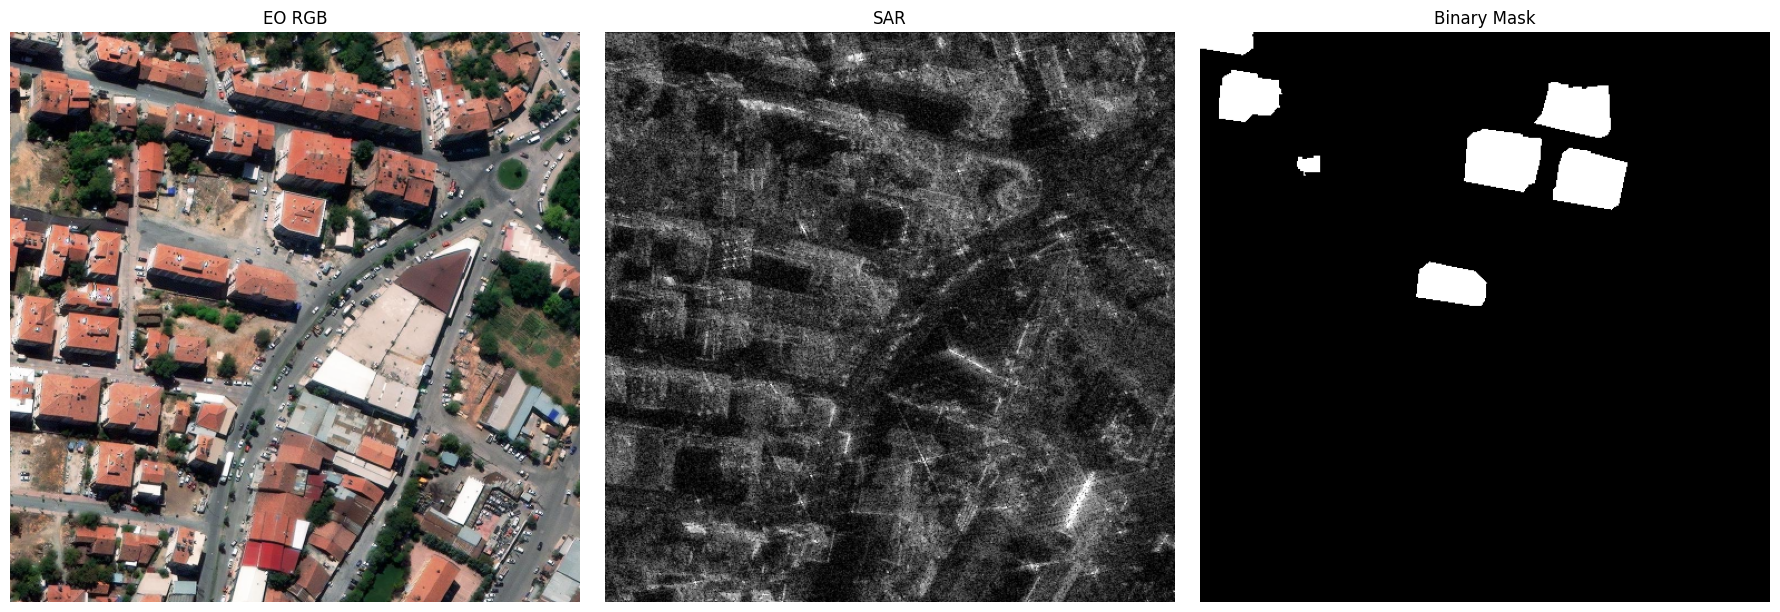

In [4]:
import numpy as np

# Convert tensor to numpy
image_np = image.numpy()
eo_image = image_np[:3]   # first 3 channels

eo_image = np.transpose(eo_image, (1,2,0))

# Denormalize for visualization
eo_image = (eo_image * np.array([0.229,0.224,0.225])) + np.array([0.485,0.456,0.406])

eo_image = np.clip(eo_image, 0, 1)

sar_image = image_np[3]

mask_np = mask.squeeze(0).numpy()

fig, axes = plt.subplots(1,3, figsize=(18,6))

axes[0].imshow(eo_image)
axes[0].set_title("EO RGB")
axes[0].axis("off")

axes[1].imshow(sar_image, cmap="gray")
axes[1].set_title("SAR")
axes[1].axis("off")

axes[2].imshow(mask_np, cmap="gray")
axes[2].set_title("Binary Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Testing Dataloader

In [5]:
dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

batch = next(iter(dataloader))

images = batch["image"]
masks = batch["mask"]

print("BATCH IMAGES SHAPE :", images.shape)
print("BATCH MASKS SHAPE  :", masks.shape)

BATCH IMAGES SHAPE : torch.Size([4, 4, 512, 512])
BATCH MASKS SHAPE  : torch.Size([4, 1, 512, 512])


## Sampling Test

In [6]:
from src.datasets.samplers import create_weighted_sampler

sampler = create_weighted_sampler(
    target_dir="../dataset/train/target",
    file_names=dataset.file_names
)

print(sampler)

In [7]:
from collections import Counter
import tifffile as tiff

sampled_indices = list(iter(sampler))

print("Number of sampled indices:", len(sampled_indices))

# Count Empty vs Non-Empty Samples
empty_count = 0
non_empty_count = 0

for idx in sampled_indices[:500]:

    file_name = dataset.file_names[idx]

    mask_path = os.path.join(
        "../dataset/train/target",
        file_name
    )

    mask = tiff.imread(mask_path)

    binary_mask = np.zeros_like(mask)

    binary_mask[
        (mask == 2) | (mask == 3)
    ] = 1

    if np.sum(binary_mask) == 0:
        empty_count += 1
    else:
        non_empty_count += 1

print("\nSAMPLED DISTRIBUTION")
print("-" * 22)

print("Empty Samples     :", empty_count)
print("Non-Empty Samples :", non_empty_count)

Number of sampled indices: 2781

SAMPLED DISTRIBUTION
----------------------
Empty Samples     : 136
Non-Empty Samples : 364


## Metric Testing

In [8]:
import torch

from src.metrics.metrics import (
    compute_iou,
    compute_precision,
    compute_recall,
    compute_f1
)

preds = torch.rand((1,1,512,512))

targets = torch.randint(
    0,
    2,
    (1,1,512,512)
).float()

print("IoU       :", compute_iou(preds, targets))
print("Precision :", compute_precision(preds, targets))
print("Recall    :", compute_recall(preds, targets))
print("F1 Score  :", compute_f1(preds, targets))

IoU       : 0.5002975463867188
Precision : 0.5002975463867188
Recall    : 1.0
F1 Score  : 0.6669306553573924


## Model Build Test

In [9]:
import torch

from src.models.unet import build_unet_model
# Create Model
model = build_unet_model()

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

# Dummy Input
dummy_input = torch.randn(
    2,
    4,
    512,
    512
).to(device)

# Forward Pass
outputs = model(dummy_input)
print("Output Shape:", outputs.shape)

Output Shape: torch.Size([2, 1, 512, 512])


## Visualisation Testing

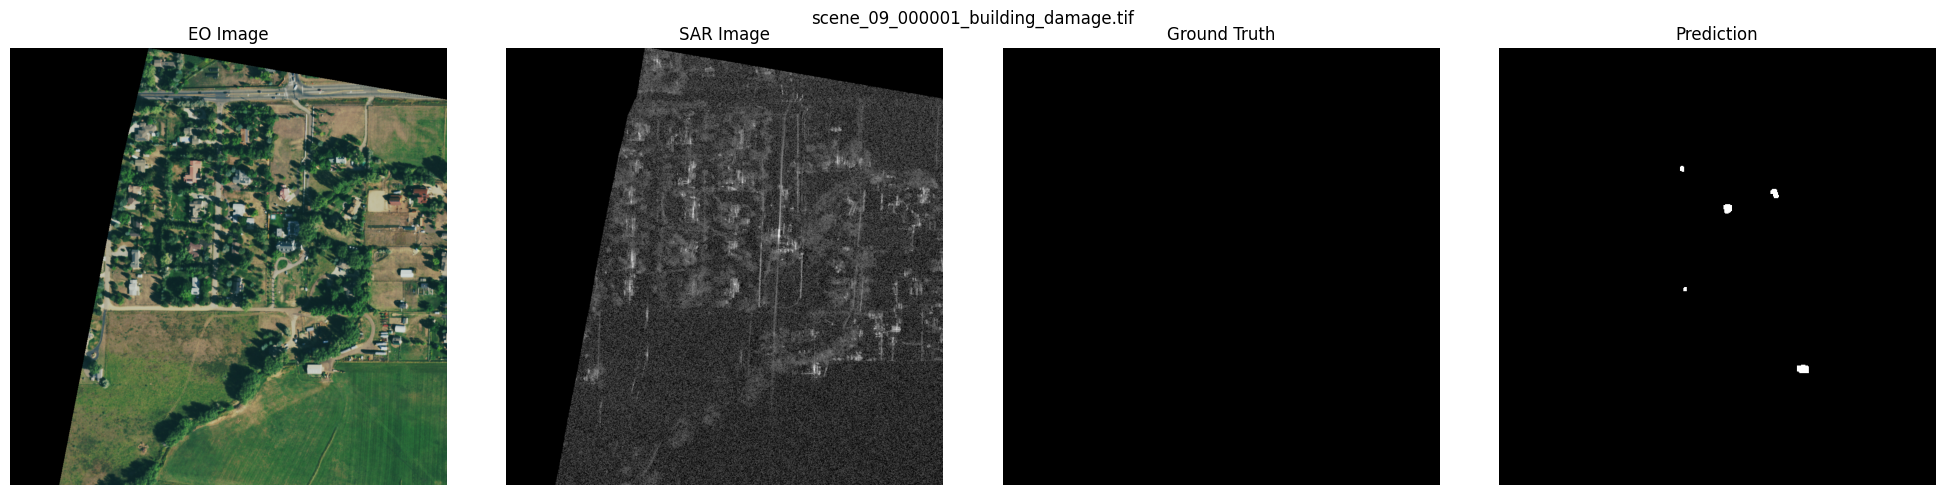

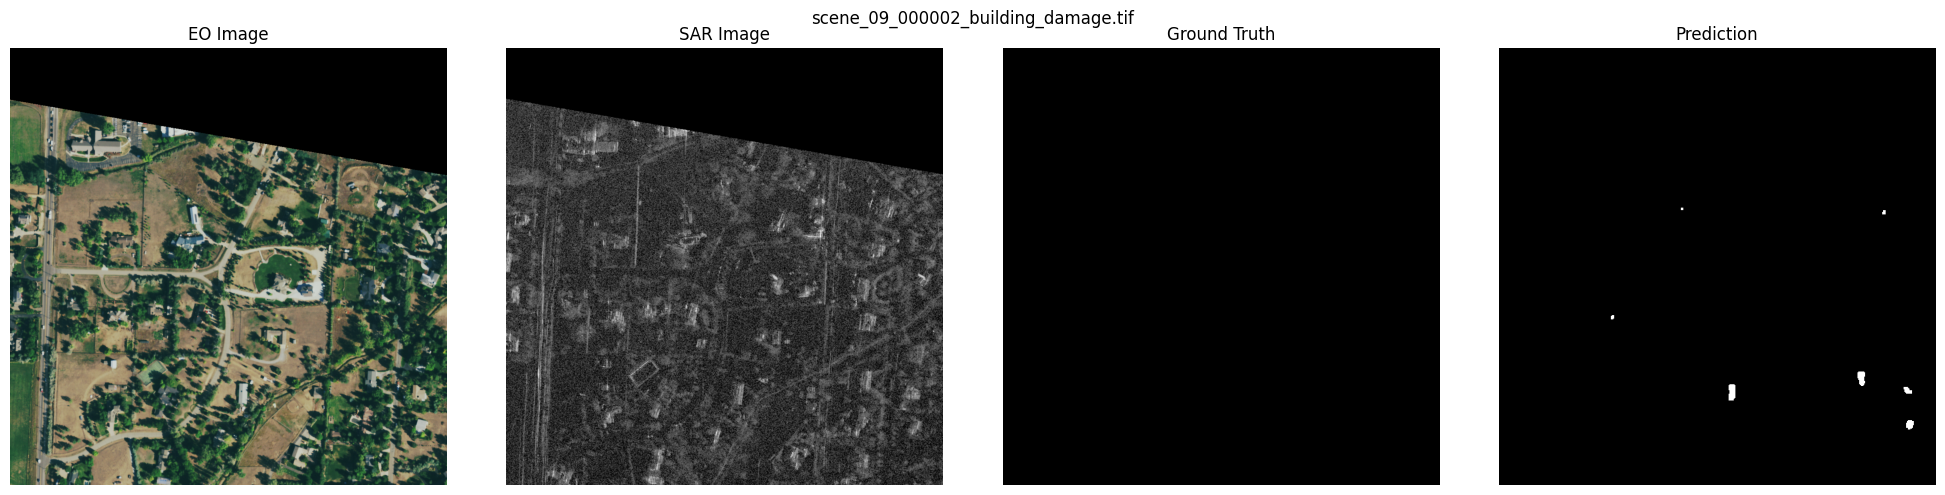

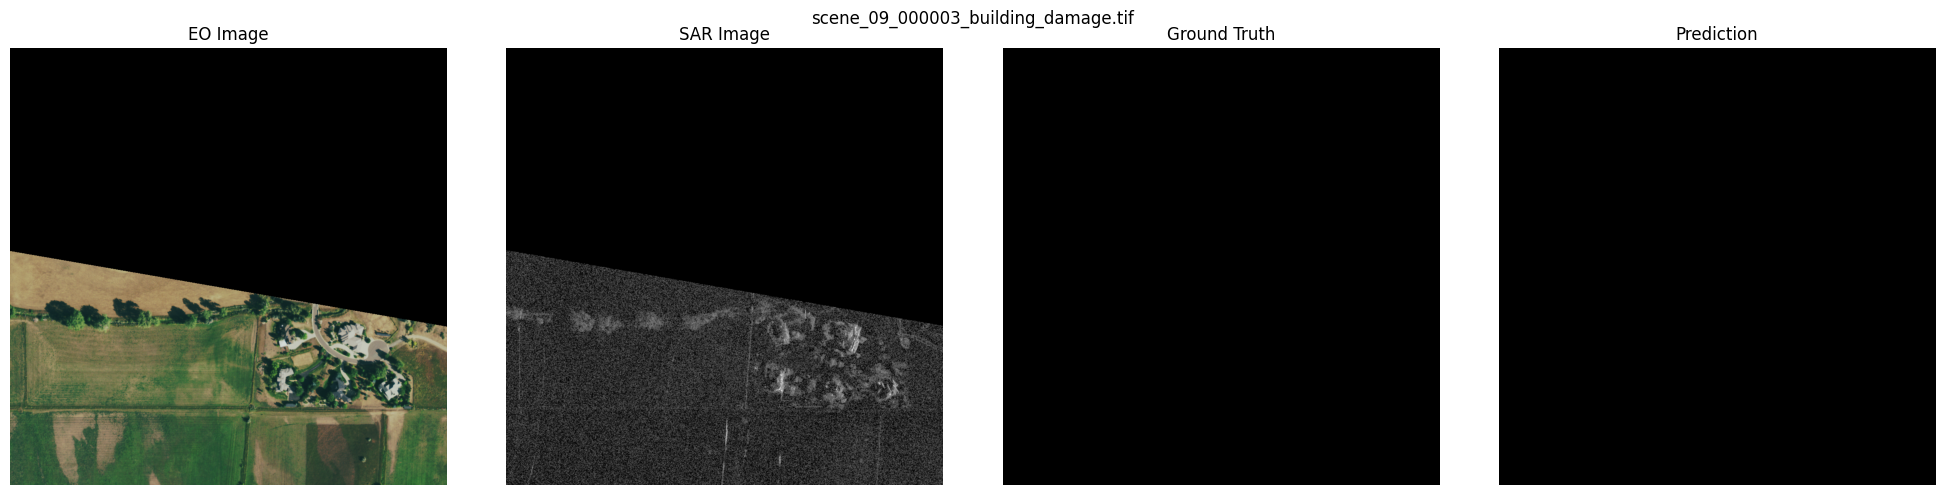

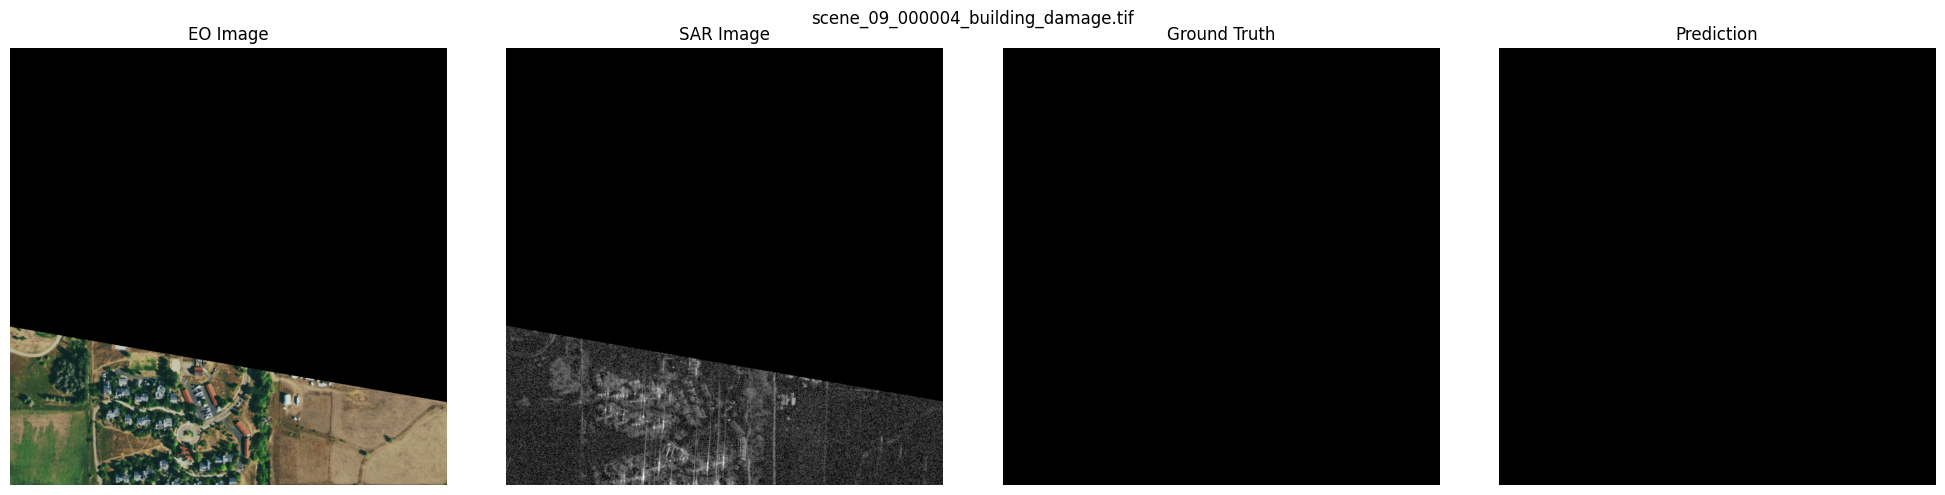

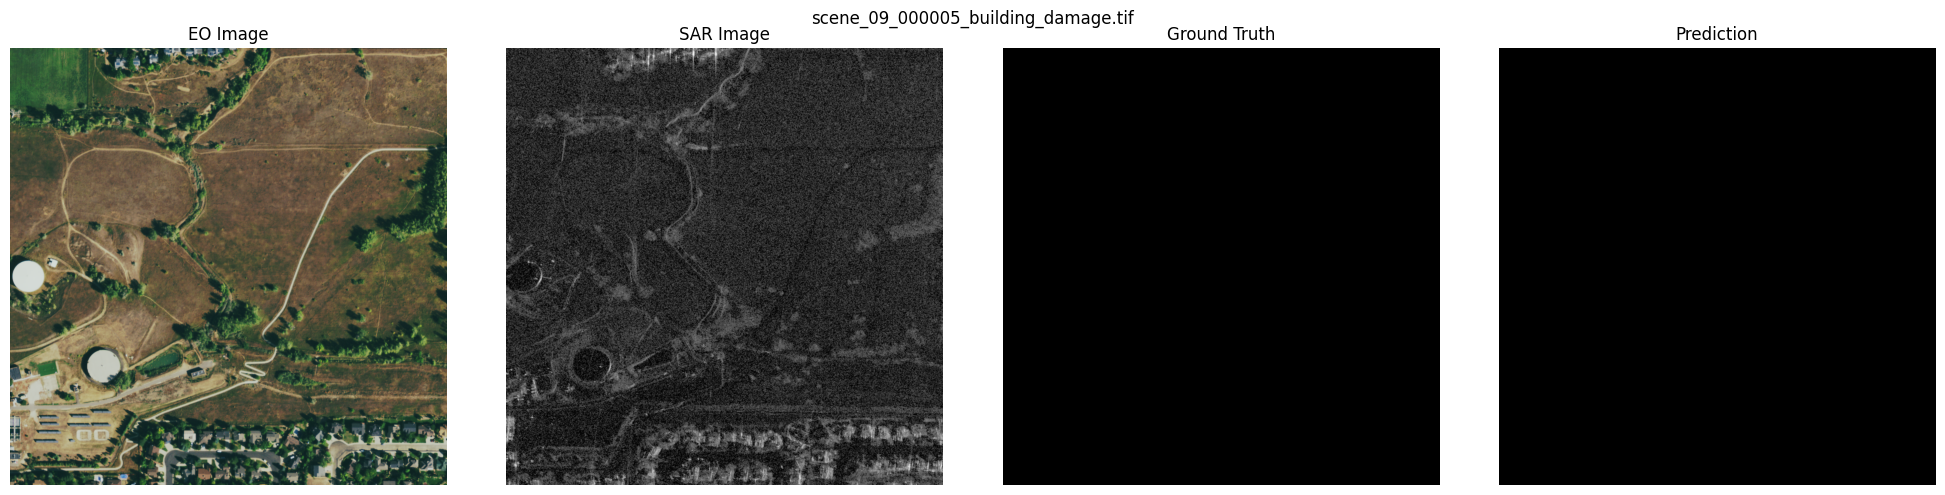

In [12]:
from src.utils.visualization import visualize_samples

visualize_samples(

    split="test",

    num_samples=5
)

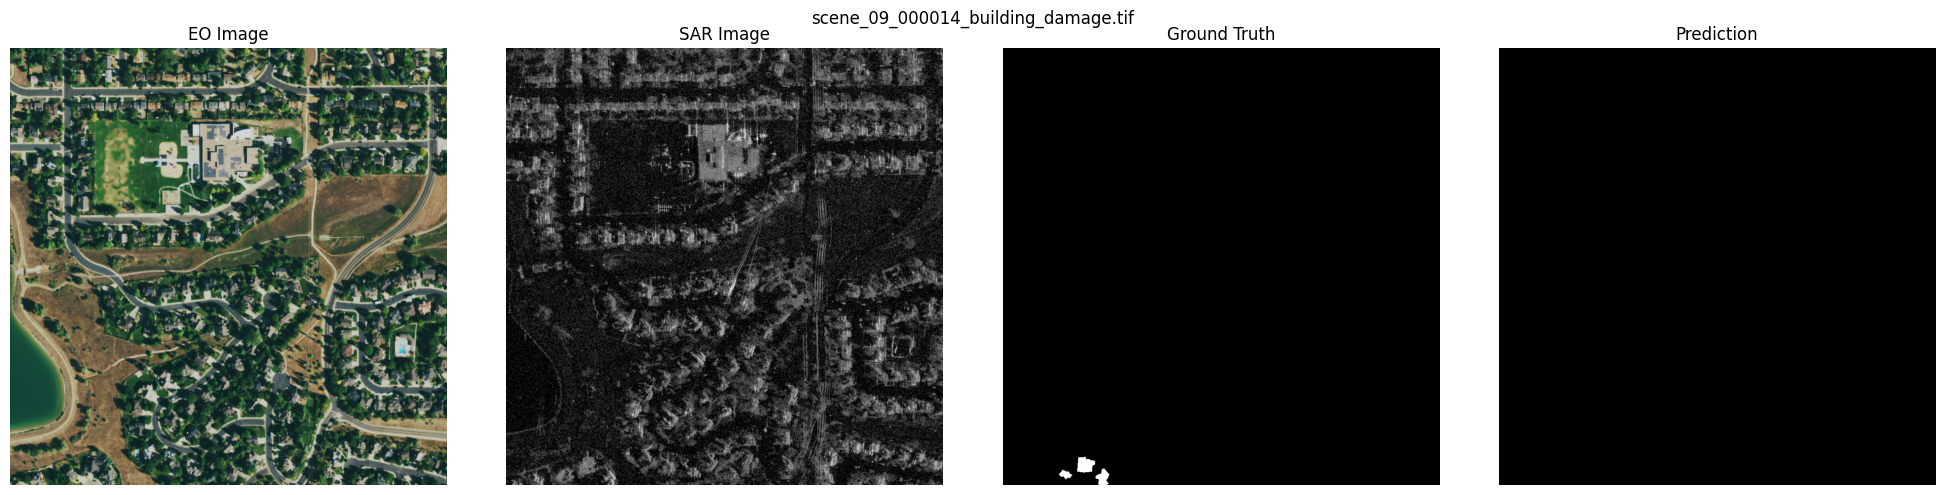

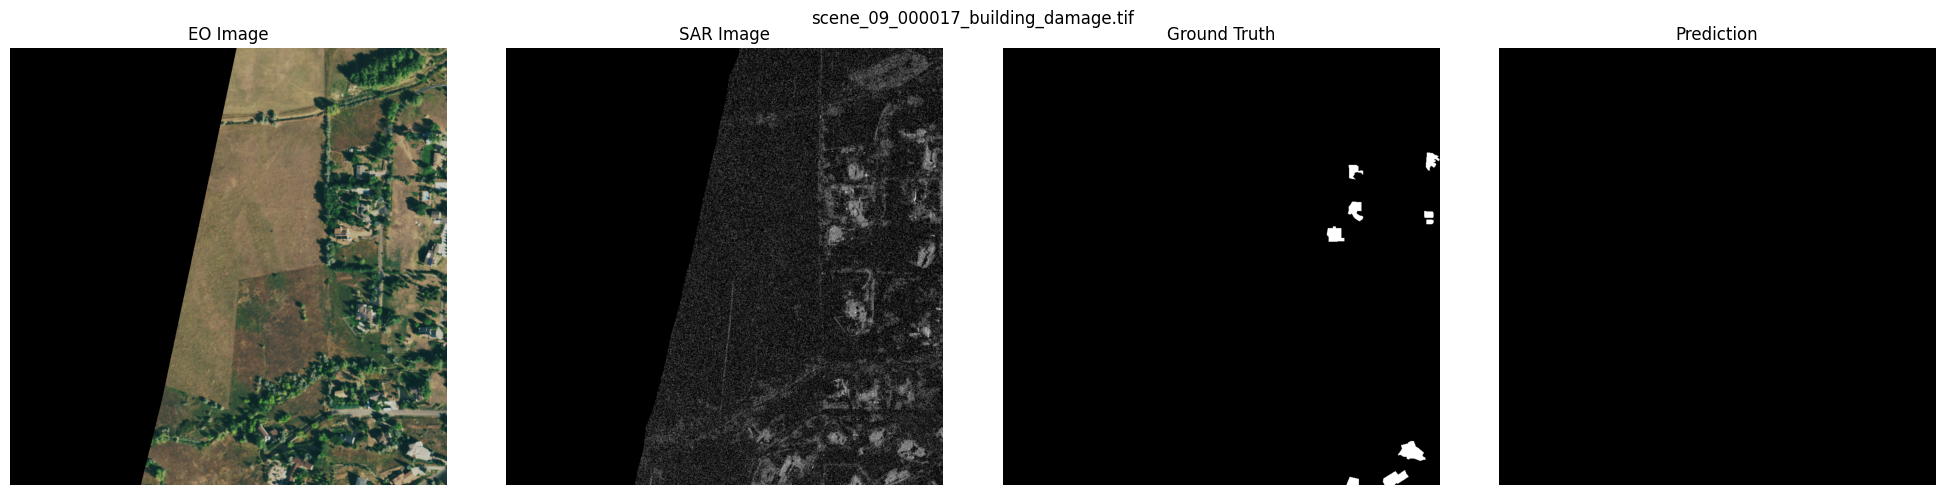

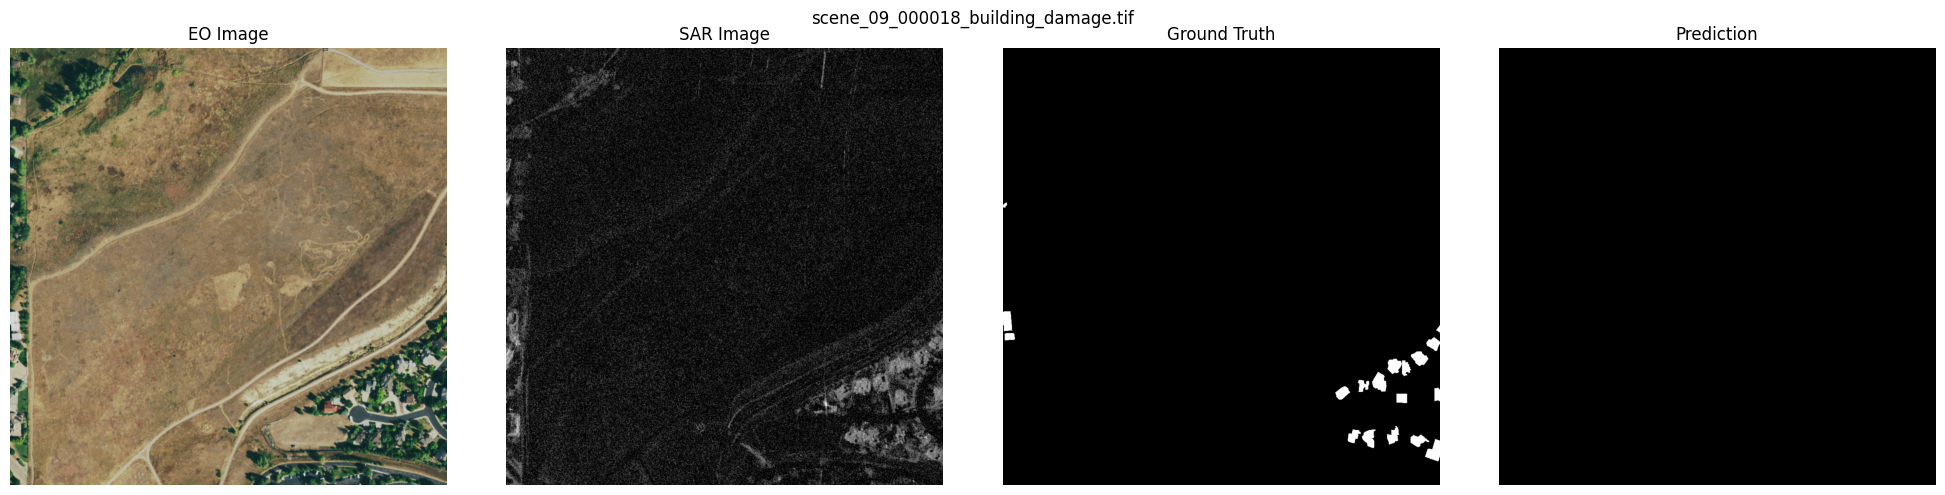

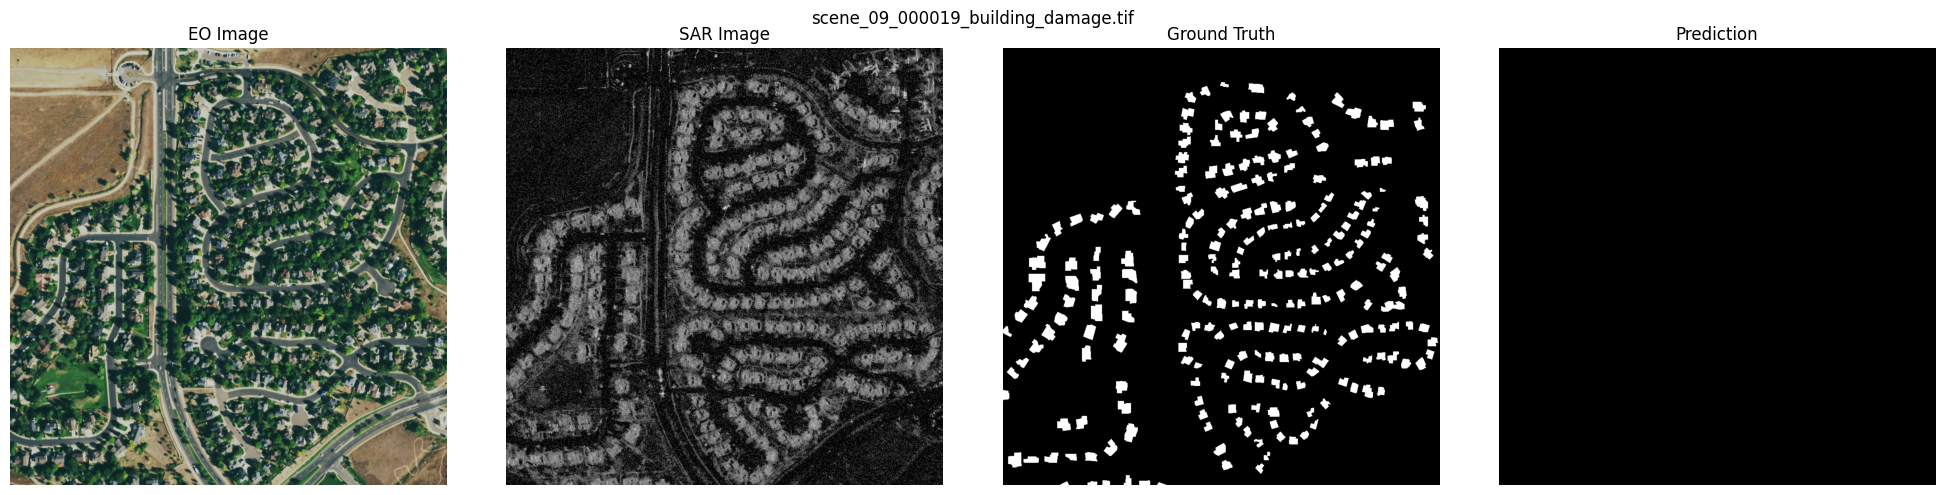

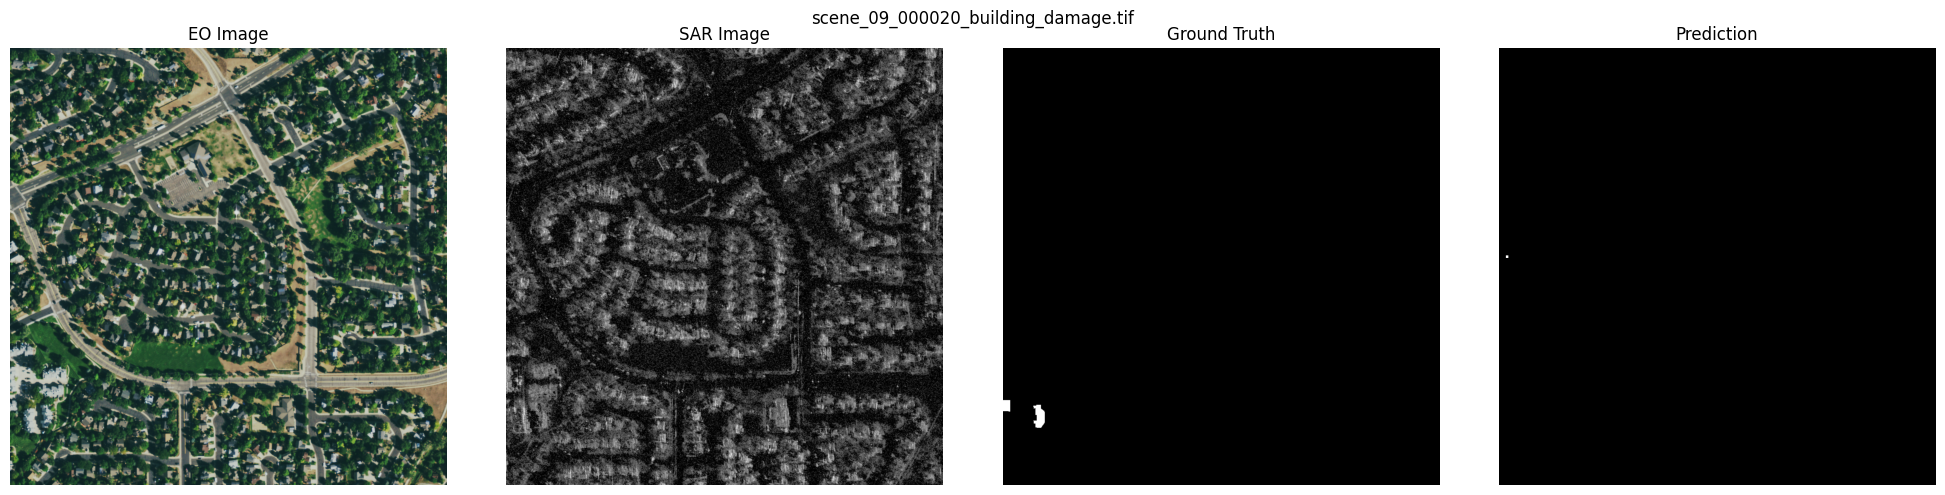

In [10]:
from src.utils.visualization import visualize_non_empty_samples

visualize_non_empty_samples(
    split="test",
    num_samples=5
)

## Checkpoint Testing

In [11]:
import torch
import torch.nn as nn

from src.utils.checkpoint import (
    save_checkpoint,
    load_checkpoint
)
# DUMMY MODEL
model = nn.Linear(10, 2)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1
)

# SAVE
save_checkpoint(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    epoch=5,
    best_iou=0.72,
    checkpoint_path="temp_checkpoint.pth"
)

# LOAD
model, optimizer, scheduler, epoch, best_iou = load_checkpoint(
    checkpoint_path="temp_checkpoint.pth",
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    device="cpu"
)

print("\nLoaded Epoch:", epoch)
print("Loaded Best IoU:", best_iou)


Checkpoint saved at: temp_checkpoint.pth

Checkpoint loaded from: temp_checkpoint.pth


ValueError: not enough values to unpack (expected 5, got 2)

## Scheduler Test

In [ ]:
import torch
import torch.nn as nn

from src.utils.scheduler import get_scheduler

model = nn.Linear(10, 2)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = get_scheduler(

    optimizer=optimizer,

    scheduler_name="cosine",

    epochs=10
)

print(scheduler)

In [ ]:
from src.utils.seed import set_seed

set_seed(42)